# 📊 Descriptive Statistics Exercise
## World Happiness Report 2026
---

> **Petunjuk Umum:**  
> - Isi setiap cell kode di bawah ini.  
> - Tulis interpretasi Anda di cell Markdown yang telah disediakan (bertanda ✏️).  
> - Jangan hapus cell yang sudah ada — tambahkan cell baru jika diperlukan.  
> - Pastikan semua cell sudah dijalankan sebelum mengumpulkan.

---
## ⚙️ Import Library

In [39]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

print('Library berhasil di-import')

Library berhasil di-import


---
# Bagian 1 – Data Preparation & Eksplorasi Awal
Sebelum melakukan analisis, kita perlu memahami struktur dataset dan memastikan data siap digunakan.

## Task 1.1 – Load & Inspect Dataset

**a.** Download *Data for Table 2.1* dari [https://www.worldhappiness.report/data-sharing/](https://www.worldhappiness.report/data-sharing/)
lalu load ke dalam DataFrame bernama `df_whr`.

In [40]:
# a. Load dataset ke dalam df_whr
# Ganti path di bawah sesuai lokasi file Anda
df_whr = pd.read_excel('WHR26_Data_Figure_2.1.xlsx')

print(f'Shape dataset: {df_whr.shape}')

Shape dataset: (2116, 13)


**b.** Tampilkan 5 baris pertama dan 5 baris terakhir dataset.

In [41]:
# b. Tampilkan 5 baris pertama
display(df_whr.head())

# 5 baris terakhir
display(df_whr.tail())

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
2111,2011,152,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2112,2011,153,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2113,2011,154,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2114,2011,155,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2115,2011,156,Togo,3.007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**c.** Cek dimensi dataset.

In [42]:
# c. Dimensi dataset
print(f'Jumlah baris  : {df_whr.shape[0]}')
print(f'Jumlah kolom  : {df_whr.shape[1]}')

Jumlah baris  : 2116
Jumlah kolom  : 13


**d.** Tampilkan daftar kolom beserta tipe datanya.

In [43]:
# d. Info kolom dan tipe data
df_whr.info()

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   str    
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by: Generosit

**e.** Cek missing values — tampilkan jumlah dan persentasenya.

In [44]:
# e. Missing values
missing = pd.DataFrame({
    'Jumlah Missing' : df_whr.isnull().sum(),
    'Persentase (%)'  : (df_whr.isnull().sum() / len(df_whr) * 100).round(2)
})
missing[missing['Jumlah Missing'] > 0]

,Jumlah Missing,Persentase (%)
Lower whisker,1094,51.70
Upper whisker,1094,51.70
Explained by: Log GDP per capita,1097,51.84
Explained by: Social support,1097,51.84
Explained by: Healthy life expectancy,1100,51.98
Explained by: Freedom to make life choices,1099,51.94
Explained by: Generosity,1097,51.84
Explained by: Perceptions of corruption,1098,51.89
Dystopia + residual,1103,52.13


**f.** Buat DataFrame `df_idn` — data Indonesia tahun 2021–2025.

In [45]:
# f. Filter data Indonesia 2021–2025
df_idn = df_whr[
    (df_whr['Country name'] == 'Indonesia') &
    (df_whr['Year'].between(2021, 2025))
].reset_index(drop=True)

print(f'Jumlah baris df_idn: {len(df_idn)}')
display(df_idn)

Jumlah baris df_idn: 5


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,87,Indonesia,5.617,5.517,5.718,1.512,1.229,0.485,1.043,0.295,0.033,1.020
1,2024,83,Indonesia,5.617,5.516,5.717,1.288,1.372,0.454,0.918,0.323,0.044,1.218
2,2023,80,Indonesia,5.568,5.466,5.670,1.361,1.184,0.472,0.779,0.399,0.055,1.318
3,2022,84,Indonesia,5.277,5.161,5.392,1.384,1.169,0.314,0.663,0.422,0.038,1.288
4,2021,87,Indonesia,5.240,5.139,5.341,1.382,0.883,0.539,0.620,0.468,0.047,1.300


In [80]:
# Filter data global 2021–2025
df_global = df_whr[
    df_whr['Year'].between(2021, 2025)
].reset_index(drop=True)

print(f'Jumlah baris df_global: {len(df_global)}')
display(df_global)

Jumlah baris df_global: 720


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041
...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,2021,142,Botswana,3.471,3.275,3.667,1.503,0.815,0.280,0.571,0.012,0.102,0.187
716,2021,143,Rwanda,3.268,3.074,3.462,0.785,0.133,0.462,0.621,0.187,0.544,0.536
717,2021,144,Zimbabwe,2.995,2.880,3.110,0.947,0.690,0.270,0.329,0.106,0.105,0.548
718,2021,145,Lebanon,2.955,2.862,3.049,1.392,0.498,0.631,0.103,0.082,0.034,0.216


## Task 1.2 – Klasifikasi Variabel

**a.** Jelaskan perbedaan variabel **Kualitatif** dan **Kuantitatif**,  
beserta sub-kategori masing-masing (Nominal, Ordinal, Diskrit, Kontinu).

✏️ *Jawaban Anda di sini:*

- **Kualitatif**  : mengeksplorasi ide, perilaku, dan pengalaman melalui data non-angka
  - Nominal       : hanya berupa label atau nama
  - Ordinal       : memiliki urutan, peringkat, atau tingkatan
- **Kuantitatif** : mengukur variabel dan menguji hipotesis menggunakan angka dan statistik
  - Diskrit       : nilai pasti, terbatas, berupa bilangan bulat, dan tidak bisa dibagi ke dalam pecahan yang lebih kecil
  - Kontinu       : nilainya tidak terbatas, bisa berbentuk desimal atau pecahan, dan nilainya berada dalam sebuah rentang/interval tertentu

**b & c.** Klasifikasikan semua kolom `df_idn` ke dalam tabel klasifikasi.

In [81]:
# b & c. Tabel klasifikasi variabel
klasifikasi = pd.DataFrame({
    'nama_kolom'    : df_idn.columns.tolist(),
    'tipe_variabel' : [
        # Isi tipe untuk setiap kolom, contoh: 'Kualitatif - Nominal'
        'Kuantitatif    - Diskrit', # year
        'Kuantitatif    - Diskrit', # rank
        'Kualitatif     - Nominal', # Country name
        'Kuantitatif    - Kontinu', # Life Ladder
        'Kuantitatif    - Kontinu', # Lower whisker
        'Kuantitatif    - Kontinu', # Upper whisker
        'Kuantitatif    - Kontinu', # Log GDP per capita
        'Kuantitatif    - Kontinu', # Social support
        'Kuantitatif    - Kontinu', # Healthy life expectancy at birth
        'Kuantitatif    - Kontinu', # Freedom to make life choices
        'Kuantitatif    - Kontinu', # Generosity
        'Kuantitatif    - Kontinu', # Perceptions of corruption
        'Kuantitatif    - Kontinu', # Dystopia + residual
    ],
    'alasan' : [
        # Isi alasan singkat untuk setiap kolom
        'Tahun adalah bilangan bulat yang bisa dihitung',
        'Rank adalah bilangan bulat yang bisa dihitung',
        'Nama negara bersifat kategorik tanpa urutan',
        'Life evaluation adalah nilai numerik yang berbentuk desimal',
        'Lower whisker adalah nilai numerik yang berbentuk desimal',
        'Upper whisker adalah nilai numerik yang berbentuk desimal',
        'Log GDP per capita adalah nilai numerik yang berbentuk desimal',
        'Social support adalah adalah nilai numerik yang berbentuk desimal',
        'Healthy life exceptancy at birth adalah nilai numerik yang berbentuk desimal',
        'Freedom to make life choises adalah nilai numerik yang berbentuk desimal',
        'Generosity adalah nilai numerik yang berbentuk desimal',
        'Perceptions of corruption adalah nilai numerik yang berbentuk desimal',
        'Distopia + residual adalah nilai numerik yang berbentuk desimal',
    ]
})
display(klasifikasi)

,nama_kolom,tipe_variabel,alasan
0,Year,Kuantitatif - Diskrit,Tahun adalah bilangan bulat yang bisa dihitung
1,Rank,Kuantitatif - Diskrit,Rank adalah bilangan bulat yang bisa dihitung
2,Country name,Kualitatif - Nominal,Nama negara bersifat kategorik tanpa urutan
3,Life evaluation (3-year average),Kuantitatif - Kontinu,Life evaluation adalah nilai numerik yang berb...
4,Lower whisker,Kuantitatif - Kontinu,Lower whisker adalah nilai numerik yang berben...
5,Upper whisker,Kuantitatif - Kontinu,Upper whisker adalah nilai numerik yang berben...
6,Explained by: Log GDP per capita,Kuantitatif - Kontinu,Log GDP per capita adalah nilai numerik yang b...
7,Explained by: Social support,Kuantitatif - Kontinu,Social support adalah adalah nilai numerik yan...
8,Explained by: Healthy life expectancy,Kuantitatif - Kontinu,Healthy life exceptancy at birth adalah nilai ...
9,Explained by: Freedom to make life choices,Kuantitatif - Kontinu,Freedom to make life choises adalah nilai nume...


**d.** ✏️ *Mengapa klasifikasi variabel penting sebelum analisis statistik?*

> Jenis variabel menentukan metode analisis yang tepat. Jika variabel salah diklasifikasikan, analisis yang dilakukan bisa menghasilkan kesimpulan yang tidak sesuai

---
# Bagian 2 – Measure of Central Tendency
Ukuran pemusatan merangkum seluruh data dengan **satu nilai representatif**.
Tiga ukuran utama: **Mean**, **Median**, dan **Mode**.

## Task 2.1 – Konsep & Implementasi Central Tendency

**a.** Hitung Mean, Median, dan Mode untuk kolom `Life Ladder`.

In [82]:
# a. Central Tendency — Life Ladder
col = df_idn["Life evaluation (3-year average)"]

mean_ll   = col.mean()
median_ll = col.median()
mode_ll   = col.mode()[0]

print(f'Mean   Life Ladder : {mean_ll:.4f}')
print(f'Median Life Ladder : {median_ll:.4f}')
print(f'Mode   Life Ladder : {mode_ll:.4f}')

Mean   Life Ladder : 5.4638
Median Life Ladder : 5.5680
Mode   Life Ladder : 5.6170


**b.** ✏️ *Ukuran central tendency mana yang paling tepat untuk `Life Ladder`? Jelaskan alasannya.*

> Median paling tepat digunakan untuk menggambarkan central tendency karena median lebih tahan terhadap outlier dibandingkan mean. Juga dikarenakan mean (5.4638) dan median (5.5680) cukup berdekatan, sehingga distribusi data tidak terlalu berbeda dari pusatnya.

**d.** Tampilkan central tendency semua kolom numerik sekaligus.

In [83]:
# d. Statistik deskriptif lengkap semua kolom numerik
numeric_cols = df_idn.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Year']

central = pd.DataFrame({
    'Mean'   : df_idn[numeric_cols].mean(),
    'Median' : df_idn[numeric_cols].median(),
    'Mode'   : df_idn[numeric_cols].mode().iloc[0],
}).round(4)

display(central)

,Mean,Median,Mode
Rank,84.2000,84.000,87.000
Life evaluation (3-year average),5.4638,5.568,5.617
Lower whisker,5.3598,5.466,5.139
Upper whisker,5.5676,5.670,5.341
Explained by: Log GDP per capita,1.3854,1.382,1.288
Explained by: Social support,1.1674,1.184,0.883
Explained by: Healthy life expectancy,0.4528,0.472,0.314
Explained by: Freedom to make life choices,0.8046,0.779,0.620
Explained by: Generosity,0.3814,0.399,0.295
Explained by: Perceptions of corruption,0.0434,0.044,0.033


**e.** Bandingkan Mean `Life Ladder` Indonesia vs rata-rata global pada tahun yang tersedia.

,Indonesia,Global Mean,Selisih
Year,,,
2025,5.617,5.6499,-0.0329
2024,5.617,5.5782,0.0388
2023,5.568,5.5276,0.0404
2022,5.277,5.5398,-0.2628
2021,5.240,5.5536,-0.3136


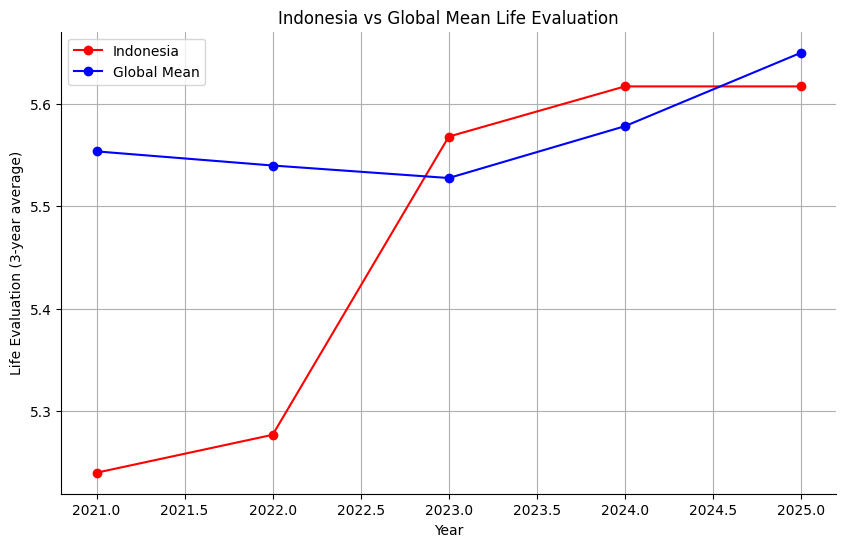

In [85]:
# e. Perbandingan Indonesia vs global
global_mean = df_whr.groupby("Year")["Life evaluation (3-year average)"].mean()
idn_series = df_idn.set_index("Year")["Life evaluation (3-year average)"]

comparison = pd.concat([idn_series, global_mean], axis=1).dropna()
comparison.columns = ["Indonesia", "Global Mean"]
comparison['Selisih'] = (comparison['Indonesia'] - comparison['Global Mean']).round(4)

display(comparison.round(4))

# Visualisasi
comparison[["Indonesia", "Global Mean"]].plot(kind="line", figsize=(10, 6), marker="o", color=["red", "blue"])

plt.title("Indonesia vs Global Mean Life Evaluation")
plt.xlabel("Year")
plt.ylabel("Life Evaluation (3-year average)")
plt.legend()
plt.grid(True)
plt.show()

✏️ *Interpretasi perbandingan Indonesia vs global:*

> Pada periode 2021-2025, skor Life Evaluation Indonesia mengalami peningkatan, terutama dari 2022 ke 2023. Pada 2021 dan 2022, skor Indonesia berada di bawah rata-rata global. Pada 2023 dan 2024, skor Indonesia berada di atas rata-rata global. Namun, pada 2025, skor Indonesia tetap sebesar sekitar 5,617 sementara rata-rata global meningkat hingga 5,6499, sehingga Indonesia kembali sedikit berada di bawah rata-rata global.

---
# Bagian 3 – Measure of Spread (Dispersi)
Ukuran penyebaran mengukur seberapa jauh data tersebar dari nilai pusatnya.

## Task 3.1 – Analisis Dispersi Data Indonesia

**a.** Hitung semua ukuran dispersi untuk `Life Ladder`.

In [86]:
# a. Ukuran dispersi — Life Ladder
col = "Life evaluation (3-year average)"
data = df_idn[col]

q1  = data.quantile(0.25)
q3  = data.quantile(0.75)
iqr = q1 - q3
std = data.std()

dispersi = {
    'Range'                     : data.max() - data.min(),
    'Variance'                  : data.var(),
    'Standard Deviation'        : std,
    'IQR (Q3 - Q1)'             : iqr,
    'Coefficient of Variation'  : (std / data.mean()) * 100,
}

for k, v in dispersi.items():
    print(f'{k:<30}: {v:.4f}')

Range                         : 0.3770
Variance                      : 0.0357
Standard Deviation            : 0.1889
IQR (Q3 - Q1)                 : -0.3400
Coefficient of Variation      : 3.4579


**c.** ✏️ *Bandingkan Std Dev Life Ladder Indonesia vs global — apa artinya bagi konsistensi kebahagiaan Indonesia?*

> Standar Deviation Life Ladder Indonesia (0.1889) lebih kecil dibandingkan Standar Deviation Global (1.1239). Artinya, tingkat kebahagiaan Indonesia lebih konsisten atau memiliki variasi yang lebih renda selama periode pengamanta, sedangkan data global menunjukkan variasi yang lebih besar.

In [87]:
# c. Std Dev Indonesia vs global
std_idn    = df_idn["Life evaluation (3-year average)"].std()
std_global = df_whr["Life evaluation (3-year average)"].std()

print(f'Std Dev Indonesia : {std_idn:.4f}')
print(f'Std Dev Global    : {std_global:.4f}')

Std Dev Indonesia : 0.1889
Std Dev Global    : 1.1239


**d.** Hitung IQR untuk semua kolom numerik. Kolom mana yang memiliki sebaran terbesar?

In [88]:
# d. IQR semua kolom numerik
q1 = df_idn[numeric_cols].quantile(0.25)
q3 = df_idn[numeric_cols].quantile(0.75)

iqr = q3 - q1

iqr_all = iqr
iqr_df  = iqr_all.sort_values(ascending=False).rename('IQR').to_frame().round(4)
display(iqr_df)

,IQR
Rank,4.000
Lower whisker,0.355
Life evaluation (3-year average),0.340
Upper whisker,0.325
Explained by: Freedom to make life choices,0.255
Explained by: Generosity,0.099
Dystopia + residual,0.082
Explained by: Social support,0.060
Explained by: Healthy life expectancy,0.031
Explained by: Log GDP per capita,0.023


**e.** Hitung CV semua kolom numerik. Kolom mana yang paling stabil?

In [89]:
# e. Coefficient of Variation semua kolom numerik
cv_all = (df_idn[numeric_cols].std() / df_idn[numeric_cols].mean() * 100)
cv_df  = cv_all.sort_values().rename('CV (%)').to_frame().round(2)
display(cv_df)

,CV (%)
Upper whisker,3.33
Life evaluation (3-year average),3.46
Rank,3.50
Lower whisker,3.60
Explained by: Log GDP per capita,5.83
Dystopia + residual,9.99
Explained by: Social support,15.25
Explained by: Healthy life expectancy,18.51
Explained by: Generosity,18.69
Explained by: Perceptions of corruption,19.46


✏️ *Kolom paling stabil berdasarkan CV adalah ... karena ...*

> Kolom yang paling stabil berdasarkan Coefficient of Variation (CV) adalah Life evaluation (3-year average) atau Life Ladder, dengan CV sebesar 3.47%. Hal ini menunjukkan bahwa Life Ladder memiliki variasi relatif paling kecil dibandingkan kolom numerik lainnya.

## Task 3.2 – Deteksi & Analisis Outlier

**a.** Deteksi outlier `Life Ladder` menggunakan metode **IQR**.

In [90]:
# a. Deteksi outlier — metode IQR
col  = "Life evaluation (3-year average)"
data = df_idn[col]

q1, q3 = data.quantile(0.25), data.quantile(0.75)
iqr    = q3 - q1
lower  = q1 - 1.5 * iqr
upper  = q3 + 1.5 * iqr

outliers_iqr = df_idn[(data < lower) | (data > upper)]

print(f'Batas bawah IQR : {lower:.4f}')
print(f'Batas atas  IQR : {upper:.4f}')
print(f'Jumlah outlier  : {len(outliers_iqr)}')
display(outliers_iqr[['Year', col]])

Batas bawah IQR : 4.7670
Batas atas  IQR : 6.1270
Jumlah outlier  : 0


,Year,Life evaluation (3-year average)


**b.** Deteksi outlier menggunakan **Z-Score** (|z| > 3). Bandingkan hasilnya.

In [91]:
# b. Deteksi outlier — metode Z-Score
col  = "Life evaluation (3-year average)"

z_scores = np.abs(stats.zscore(df_idn[col]))
outliers_zscore = df_idn[z_scores > 3]

print(f'Jumlah outlier Z-Score (|z|>3) : {len(outliers_zscore)}')
display(outliers_zscore[['Year', col]])

print(f'\nPerbandingan:')
print(f'  IQR    : {len(outliers_iqr)} outlier')
print(f'  Z-Score: {len(outliers_zscore)} outlier')

Jumlah outlier Z-Score (|z|>3) : 0


,Year,Life evaluation (3-year average)



Perbandingan:
  IQR    : 0 outlier
  Z-Score: 0 outlier


**c.** Visualisasi outlier dengan Boxplot.

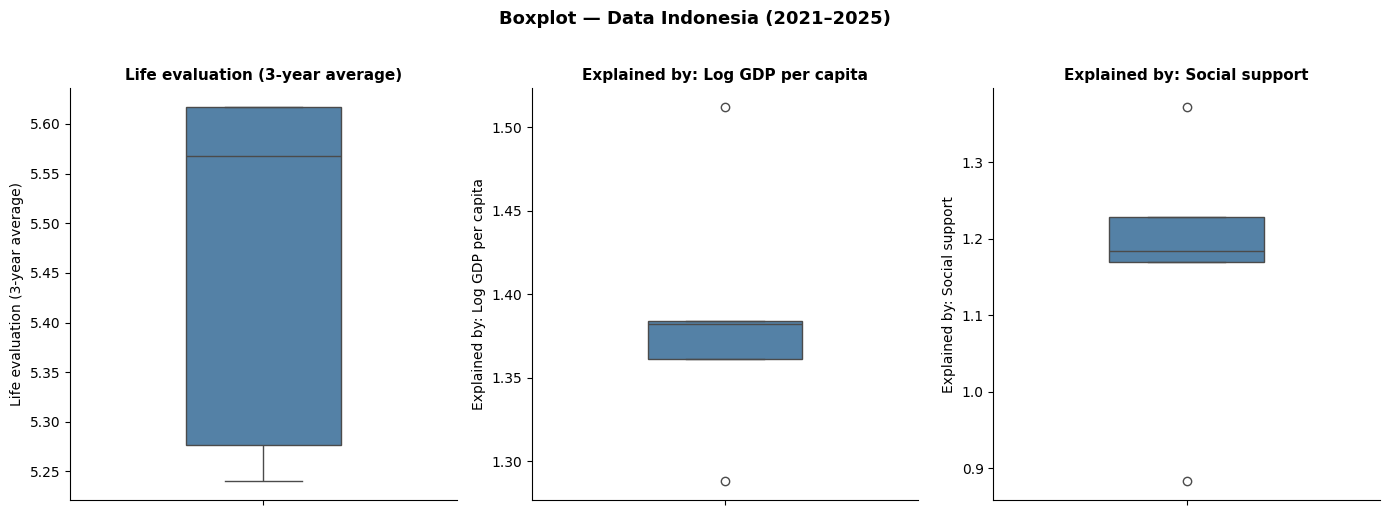

In [92]:
# c. Boxplot — Life Ladder, Log GDP per capita, Social support
cols_box = ['Life evaluation (3-year average)', 'Explained by: Log GDP per capita', 'Explained by: Social support']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, c in zip(axes, cols_box):
    sns.boxplot(y=df_idn[c], ax=ax, color='steelblue', width=0.4)
    ax.set_title(c, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

fig.suptitle('Boxplot — Data Indonesia (2021–2025)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**d.** ✏️ *Identifikasi tahun outlier dan jelaskan kemungkinan penyebabnya.*

> Tidak terdapat tahun yang teridentifikasi sebagai outlier pada Life Ladder Indonesia berdasarkan metode IQR maupun Z-Score. Hal ini kemungkinan karena nilai Life Ladder Indonesia selama periode pengamatan berada dalam rentang yang relatif wajar dan tidak memiliki perubahan yang sangat ekstrem dibandingkan keseluruhan data. Perubahan nilai dari tahun ke tahun masih berada dalam batas variasi data, sehingga tidak dikategorikan sebagai outlier.

---
# Bagian 4 – Analisis Distribusi Data
Distribusi data menggambarkan pola penyebaran nilai — apakah simetris, skewed kanan, atau skewed kiri.

## Task 4.1 – Eksplorasi Distribusi

**a.** Buat Histogram untuk semua kolom numerik dalam satu figure.

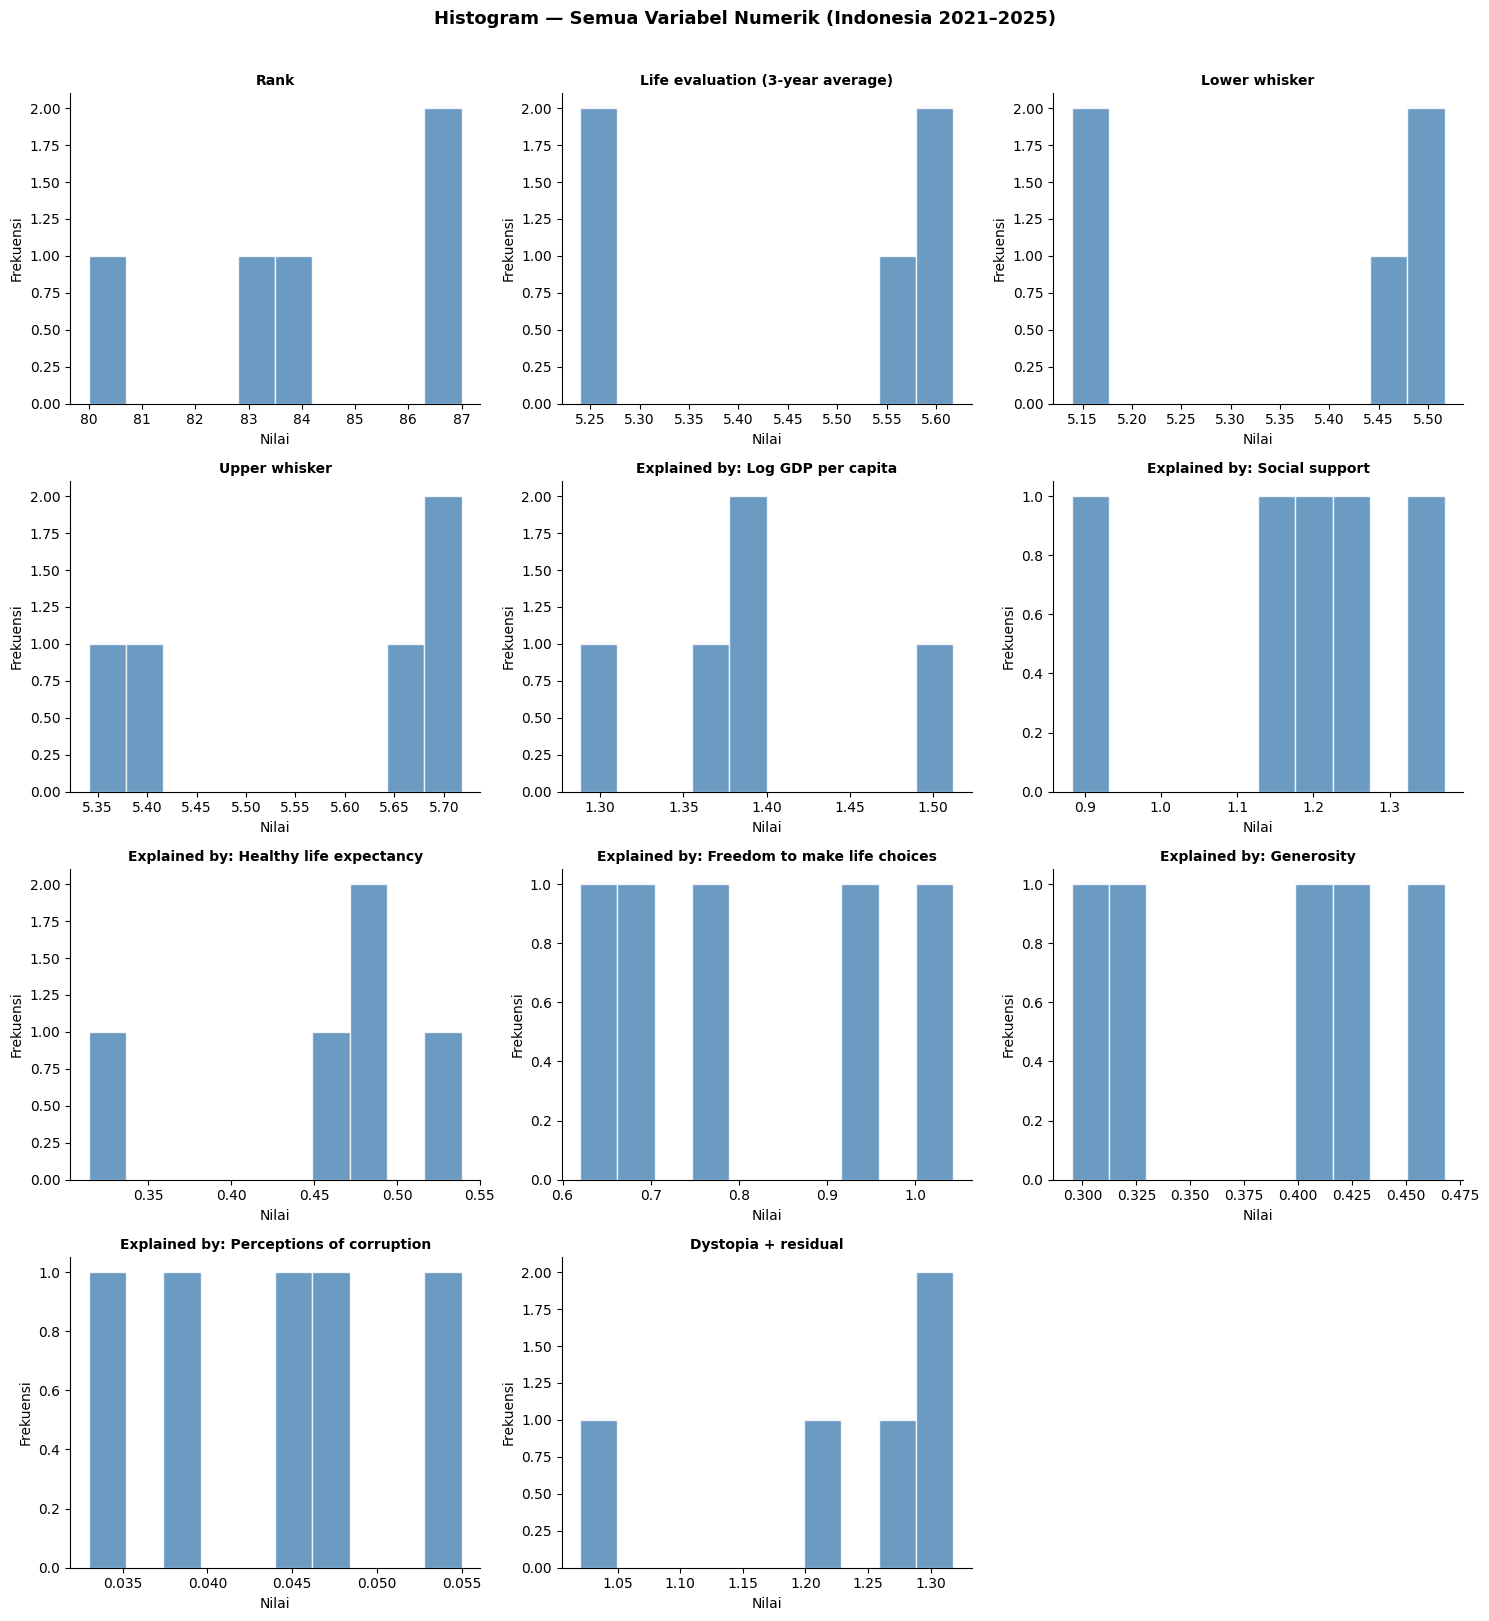

In [93]:
# a. Histogram semua kolom numerik
n     = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_idn[col].dropna(), bins=10, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai'); axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histogram — Semua Variabel Numerik (Indonesia 2021–2025)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**b.** Hitung Skewness dan Kurtosis setiap kolom numerik.

In [107]:
# b. Skewness dan Kurtosis
sk_kurt = pd.DataFrame({
    'Skewness' : df_idn[numeric_cols].skew(),
    'Kurtosis' : df_idn[numeric_cols].kurt(),
}).round(4)

display(sk_kurt)

,Skewness,Kurtosis
Rank,-0.5183,-0.7967
Life evaluation (3-year average),-0.5811,-3.1477
Lower whisker,-0.5657,-3.2292
Upper whisker,-0.6033,-3.0284
Explained by: Log GDP per capita,0.8609,2.1766
Explained by: Social support,-1.0481,2.3328
Explained by: Healthy life expectancy,-1.4102,2.8280
Explained by: Freedom to make life choices,0.4449,-1.5987
Explained by: Generosity,-0.1406,-1.8848
Explained by: Perceptions of corruption,0.2252,-0.4210


**c.** ✏️ *Tentukan distribusi setiap kolom berdasarkan nilai skewness dan interpretasikan:*

| Kolom | Skewness | Jenis Distribusi | Interpretasi |
|-------|----------|------------------|--------------|
| Life Ladder | -0.5811 | Left-skewed | Distribusi miring ke kiri secara moderat |
| Log GDP per capita | 0.8609 | Right-skewed | Distribusi miring ke kanan secara moderat |
| Social support | -1.0481 | Left-skewed | Distribusi miring ke kiri secara kuat |
| Healthy life expectancy | -1.4102 | Left-skewed | Distribusi miring ke kiri secara kuat |
| Freedom to make life choices | 0.4449 | Relatively symmetric | Distribusi relatif simetris |
| Generosity | -0.1406 | Relatively symmetric | Distribusi relatif simetris |
| Perceptions of corruption | 0.2252 | Relatively symmetric | Distribusi relatif simetris |
| Dystopia + residual | -1.7642 | Left-skewed | Distribusi miring ke kiri secara kuat |

**d.** Buat KDE Plot overlay di atas Histogram untuk `Life Ladder` dan `Log GDP per capita`.

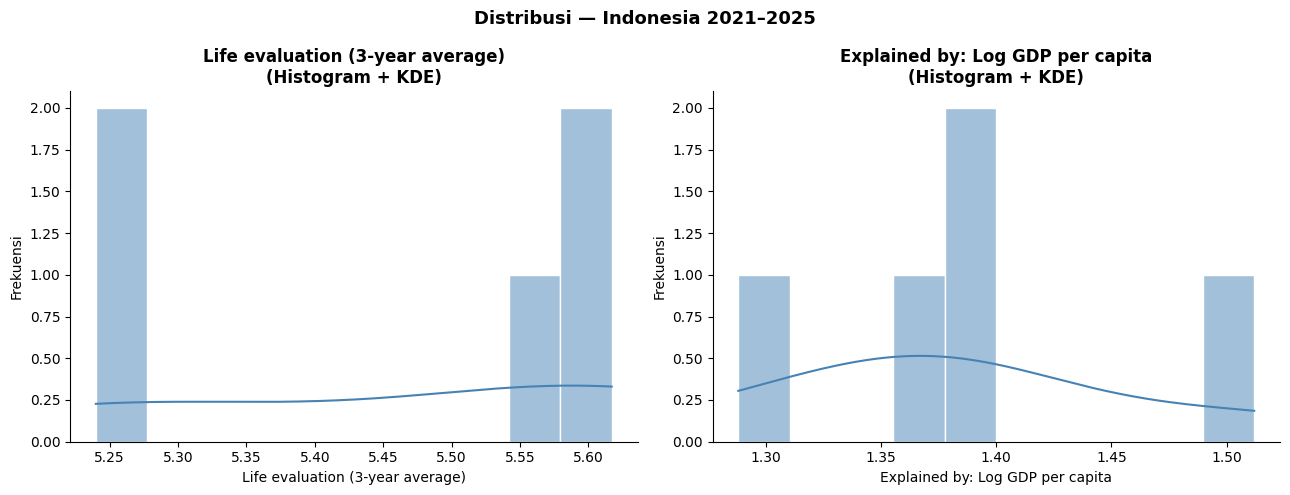

In [95]:
# d. Histogram + KDE — Life Ladder & Log GDP per capita
cols_kde = ['Life evaluation (3-year average)', 'Explained by: Log GDP per capita']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, cols_kde):
    sns.histplot(df_idn[col].dropna(), bins=10, kde=True, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{col}\n(Histogram + KDE)', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Frekuensi')

plt.suptitle('Distribusi — Indonesia 2021–2025', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**e.** Bandingkan distribusi `Life Ladder` Indonesia vs global tahun 2025.

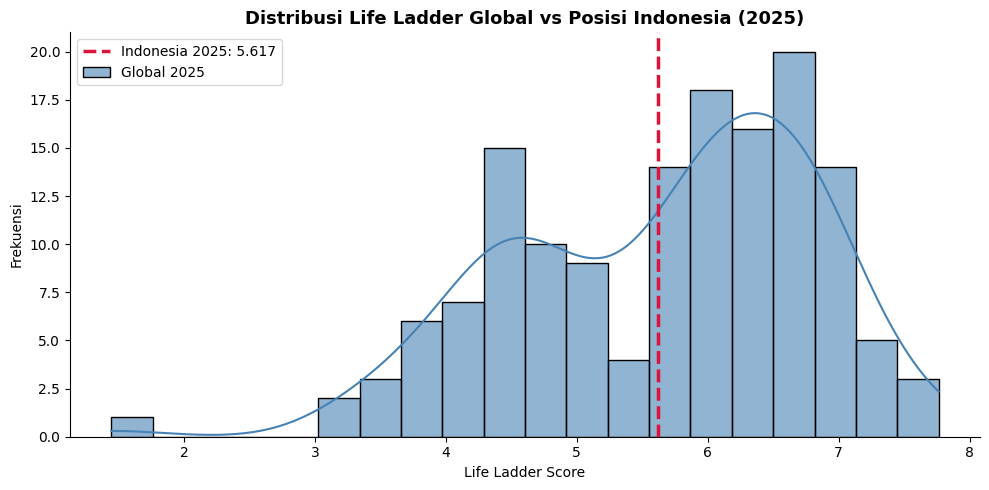

In [97]:
# e. Indonesia vs Global — Life Ladder 2025
global_2025 = df_whr[df_whr['Year'] == 2025]['Life evaluation (3-year average)'].dropna()
idn_2025    = df_idn[df_idn['Year'] == 2025]['Life evaluation (3-year average)']

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(global_2025, bins=20, kde=True, ax=ax, color='steelblue', alpha=0.6, label='Global 2025')

if len(idn_2025) > 0:
    ax.axvline(idn_2025.values[0], color='crimson', linewidth=2.5, linestyle='--', label=f'Indonesia 2025: {idn_2025.values[0]:.3f}')

ax.set_title('Distribusi Life Ladder Global vs Posisi Indonesia (2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score'); ax.set_ylabel('Frekuensi')
ax.legend(); plt.tight_layout(); plt.show()

✏️ *Interpretasi posisi Indonesia dibandingkan distribusi global 2025:*

> Pada tahun 2025, Indonesia memiliki skor Life Ladder sebesar 5,617. Posisi ini berada di dalam distribusi global, tetapi cenderung berada di bagian tengah hingga sedikit di bawah pusat distribusi. Sebagian besar negara dalam data global memiliki sekor sekitar 5,5-7,0, sementara Indonesia berada pada skor 5,617. Dengan demikian, skor Life Ladder Indonesia masih berada dalam rentang yang umum ditemukan secara global dan bukan termasuk nilai yang paling tinggi maupun paling rendah.

---
# Bagian 5 – Visualisasi & Analisis Hubungan Antar Variabel
Visualisasi yang tepat membantu mengkomunikasikan temuan secara efektif.

## Task 5.1 – Visualisasi Tren & Komparasi

**a.** Line Chart tren `Life Ladder` Indonesia 2021–2025 dengan anotasi titik tertinggi & terendah.

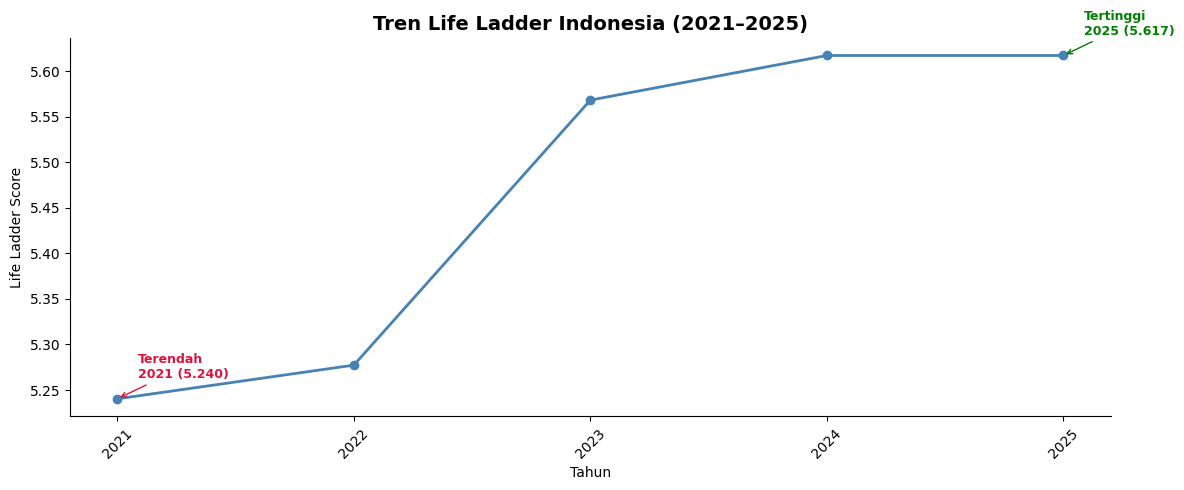

In [98]:
# a. Line Chart — Tren Life Ladder Indonesia
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_idn['Year'], df_idn['Life evaluation (3-year average)'], marker='o',
        color='steelblue', linewidth=2, markersize=6)

# Anotasi titik tertinggi dan terendah
idx_max = df_idn['Life evaluation (3-year average)'].idxmax()
idx_min = df_idn['Life evaluation (3-year average)'].idxmin()

for idx, label, color in [(idx_max, 'Tertinggi', 'green'), (idx_min, 'Terendah', 'crimson')]:
    ax.annotate(
        f"{label}\n{df_idn.loc[idx, 'Year']} ({df_idn.loc[idx, 'Life evaluation (3-year average)']:.3f})",
        xy=(df_idn.loc[idx, 'Year'], df_idn.loc[idx, 'Life evaluation (3-year average)']),
        xytext=(15, 15), textcoords='offset points',
        fontsize=9, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color)
    )

ax.set_title('Tren Life Ladder Indonesia (2021–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Life Ladder Score')
ax.set_xticks(df_idn['Year']); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

**b.** Bar Chart — rata-rata `Life Ladder` negara-negara ASEAN tahun 2021-2025.

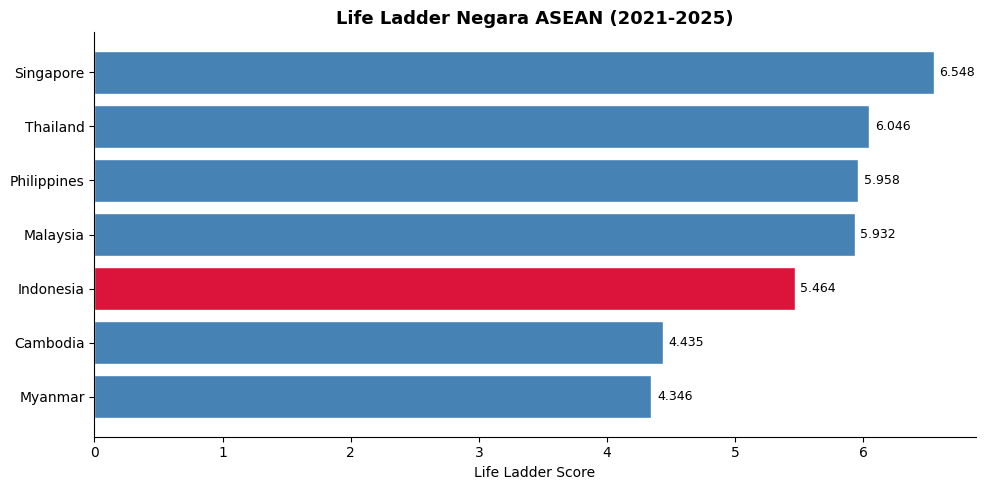

In [99]:
# b. Bar Chart — Life Ladder ASEAN 2021-2025
asean = ['Indonesia', 'Thailand', 'Philippines', 'Vietnam', 'Malaysia', 'Singapore', 'Myanmar', 'Cambodia', 'Laos', 'Brunei Darussalam']

asean_avg_5y = (df_whr[(df_whr['Year'].between(2021, 2025)) & (df_whr['Country name'].isin(asean))]
                .groupby('Country name')["Life evaluation (3-year average)"].mean().sort_values())

colors = ['crimson' if c == 'Indonesia' else 'steelblue' for c in asean_avg_5y.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(asean_avg_5y.index, asean_avg_5y.values, color=colors, edgecolor='white')

ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_title('Life Ladder Negara ASEAN (2021-2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score')

plt.tight_layout()
plt.show()

**c.** ✏️ *Jelaskan kapan sebaiknya menggunakan Line Chart vs Bar Chart:*

> - Line Chart sebaiknya digunakan untuk melihat tren atau perubahan data dari waktu ke waktu. Contohnya pada grafik Tren Life Ladder Indonesia (2021-2025), line chart cocok karena kita ingin melihat bagaimana nilai Life Ladder Indonesia berubah setiap tahun.
> - Bar Chart sebaiknya digunakan untuk membandingkan nilai antara beberapa kategori atau kelompok. Contohnya pada grafik Life Ladder Negara ASEAN (2021-2025), bar chart cocok karena kita ingin membandingkan rata-rata Life Ladder antarnegara ASEAN.

**d.** Heatmap nilai semua variabel numerik Indonesia per tahun.

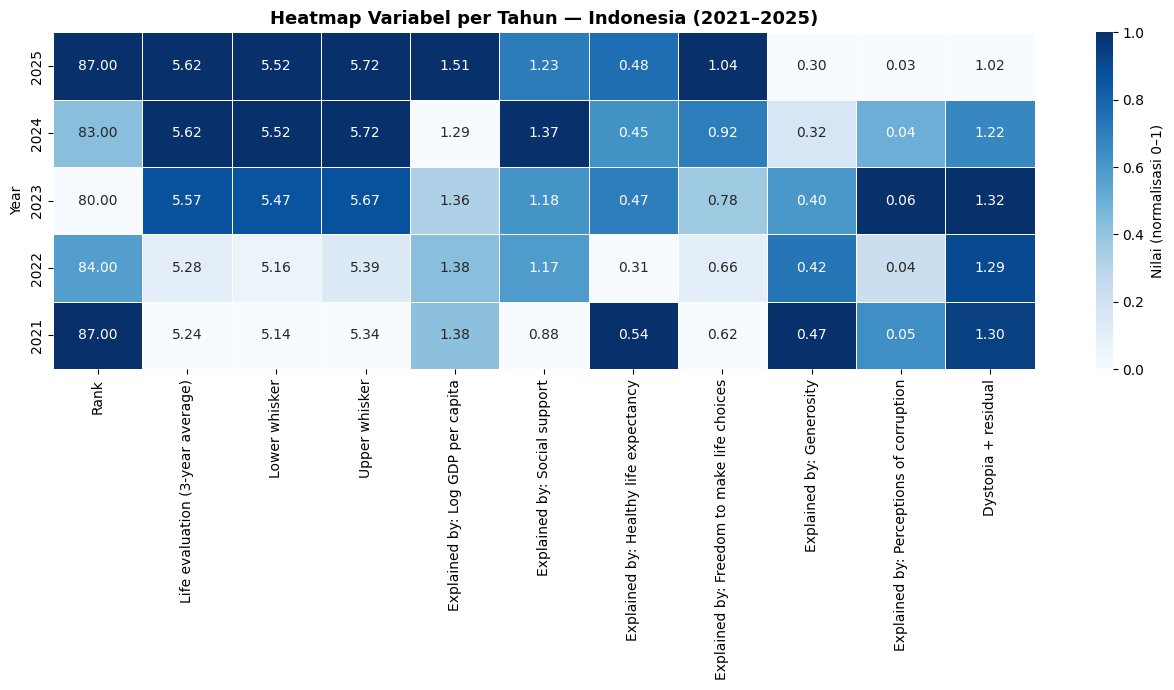

In [100]:
# d. Heatmap — nilai variabel per tahun
heatmap_data = df_idn.set_index('Year')[numeric_cols]

# Normalisasi 0–1 agar skala sebanding
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(2), fmt='.2f', cmap='Blues', linewidths=0.5, ax=ax, cbar_kws={'label': 'Nilai (normalisasi 0–1)'})
ax.set_title('Heatmap Variabel per Tahun — Indonesia (2021–2025)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Task 5.2 – Analisis Korelasi & Scatter Plot

**a & b.** Scatter Plot 4 pasang variabel + Koefisien Korelasi Pearson.

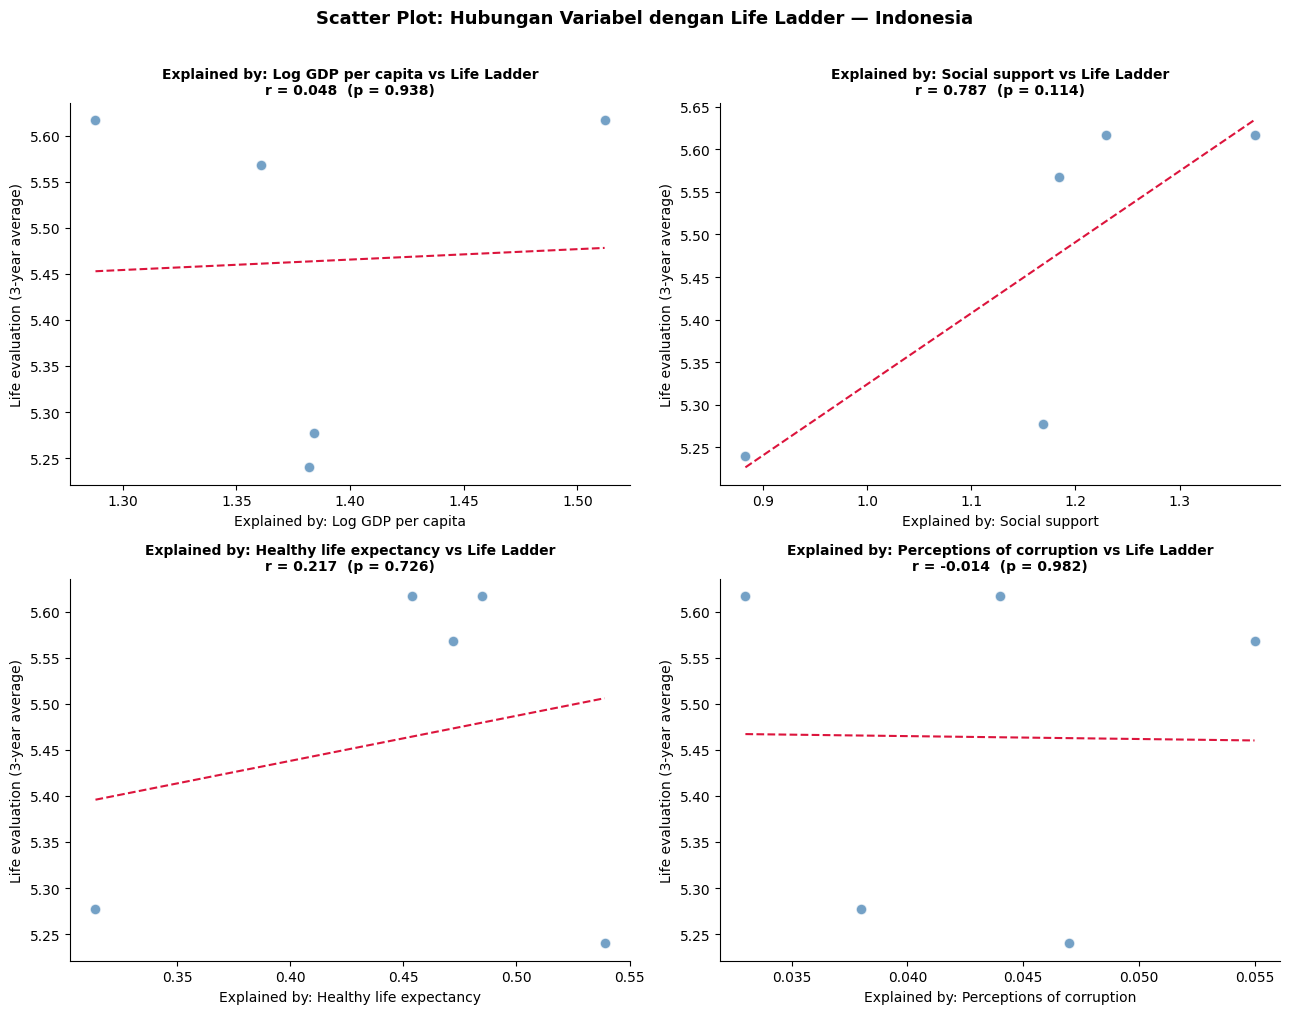

In [101]:
# a & b. Scatter Plot + Korelasi Pearson
pairs = [
    ('Explained by: Log GDP per capita',                'Life evaluation (3-year average)'),
    ('Explained by: Social support',                    'Life evaluation (3-year average)'),
    ('Explained by: Healthy life expectancy',           'Life evaluation (3-year average)'),
    ('Explained by: Perceptions of corruption',         'Life evaluation (3-year average)'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, pairs):
    valid = df_idn[[x_col, y_col]].dropna()
    r, p  = stats.pearsonr(valid[x_col], valid[y_col])

    ax.scatter(valid[x_col], valid[y_col], color='steelblue', alpha=0.75, edgecolor='white', s=60)

    # Trend line
    m, b = np.polyfit(valid[x_col], valid[y_col], 1)
    x_line = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5, linestyle='--')

    ax.set_title(f'{x_col} vs Life Ladder\nr = {r:.3f}  (p = {p:.3f})', fontsize=10, fontweight='bold')
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)

plt.suptitle('Scatter Plot: Hubungan Variabel dengan Life Ladder — Indonesia', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

✏️ *Interpretasi korelasi setiap pasang variabel:*

| Pasang Variabel | r | Interpretasi |
|---|---|---|
| Log GDP vs Life Ladder | 0.048 | Korelasi positif sangat lemah/hampir tidak ada. Hubungan linear antara Log GDP per capita dan Life Ladder sangat lemah |
| Social support vs Life Ladder | 0.787 | Korelasi positif kuat. Semakin tinggi social support, Life Ladder cenderung lebih tinggi |
| Life expectancy vs Life Ladder | 0.217 | Korelasi positif lemah. Hubungan antara healthy life expectancy dan Life Ladder cenderung positif, tetapi lemah |
| Corruption vs Life Ladder | -0.014 | Korelasi negatif sangat lemah/hampir tidak ada. Hampir tidak terdapat hubungan linear antara perceptions of corruption dan Life Ladder |

Kesimpulan singkat:
- Social support memiliki korelasi paling kuat dengan Life Ladder (r = 0.787)
- Life expectancy memiliki korelasi positif tetapi lemah (r = 0.217)
- Log GDP per capita hampir tidak memiliki korelasi dengan Life Ladder (r = 0.048)
- Perceptions of corruption juga hampir tidak memiliki korelasi dengan Life Ladder (r  = -0.014)

**c.** Correlation Heatmap semua variabel numerik.

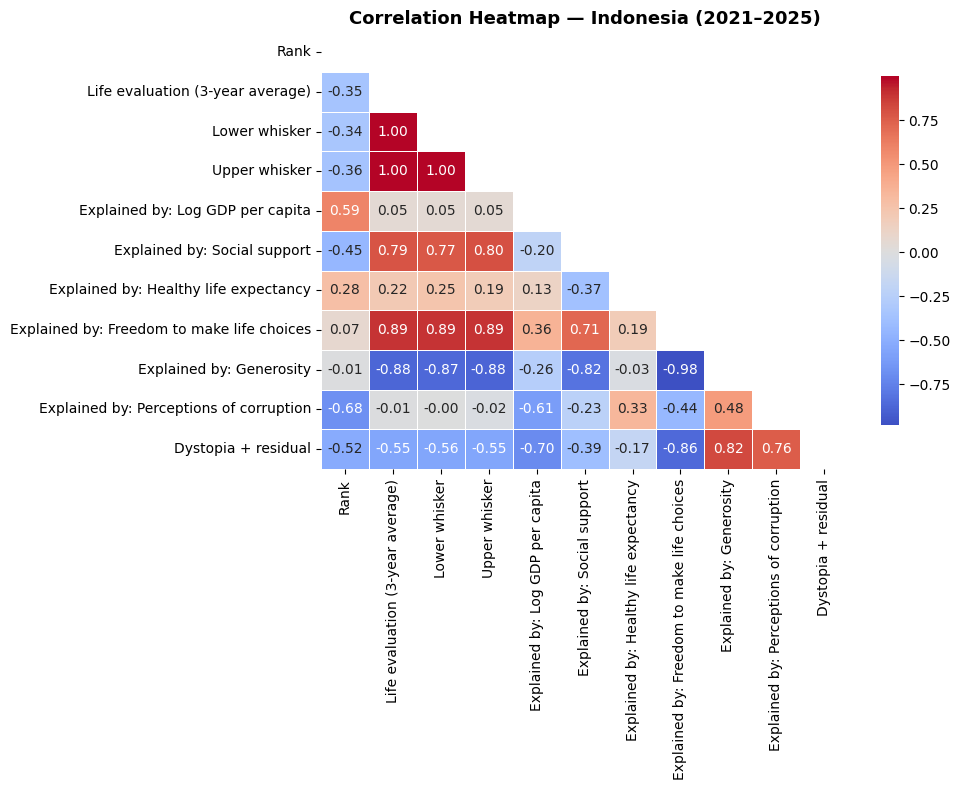

In [103]:
# c. Correlation Heatmap
corr = df_idn[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Indonesia (2021–2025)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

✏️ *Variabel yang paling berkorelasi dengan Life Ladder adalah Social support dengan nilai r = 0.787*

> Terdapat korelasi positif kuat antara social support dan Life Ladder. Dalam data Indonesia 2021-2025, nilai social support yang lebih tinggi cenderung disertai nilai Life Ladder yang lebih tinggi.

**d.** ✏️ *Jelaskan perbedaan korelasi dan kausalitas, serta berikan contoh dari data WHR ini:*

> - Korelasi adalah hubungan atau keterkaitan antara dua variabel. Korelasi menunjukkan bahwa ketika satu variabel berubah, variabel lainnya cenderung ikut berubah. Namun, korelasi tidak membuktikan bahwa satu variabel menyebabkan variabel lainnya.
> - Kasualitas berarti terdapat hubungan sebab-akibat, yaitu perubahan pada satu variabel secara langsung menyebabkan perubahan pada variabel lainnya.\
\
> Contoh dari data WHR:\
> Data menunjukkan bahwa social support dan Life Ladder memiliki korelasi positif kuat (r = 0.787). Ini berarti keduanya cenderung meningkat atau menurun bersama. Namun, kita tidak dapat menyimpulkan bahwa social support menyebabkan Life Ladder meningkat. Bisa saja terdapat faktor lain yang memengaruhi keduanya, misalnya kondisi ekonomi, kesehatan, atau faktor sosial lainnya.

---
# Bagian 6 – Insight & Pelaporan
Analisis yang baik tidak hanya menghasilkan angka, tetapi juga **cerita bermakna** dari data.

## Task 6.1 – Ringkasan Analisis & Insight

**a.** ✏️ *Tuliskan minimal 5 insight dari analisis Anda:*

1. **Life Evaluation Indonesia meningkat secara keseluruhan**, dari 5,240 pada 2021 menjadi 5,617 pada 2025, meskipun sempat meningkat dan kemudian stabil.
2. **Rata-rata Life Evaluation Indonesia 2021–2025 adalah 5,464**, dengan nilai tertinggi 5,617 pada 2024 dan 2025.
3. **Indonesia berada di bawah rata-rata global pada 2021–2022 dan 2025**, tetapi sedikit di atas rata-rata global pada 2023–2024.
4. **Tidak ditemukan outlier** pada Life Evaluation Indonesia berdasarkan metode IQR maupun Z-Score.
5. **Freedom to make life choices memiliki korelasi positif sangat kuat (r = 0,893)** dengan Life Evaluation, sedangkan Generosity memiliki korelasi negatif kuat (r = -0,878). Hasil ini bersifat korelasional dan menggunakan lima observasi.
6. Dalam perbandingan ASEAN berdasarkan rata-rata 2021–2025, **Indonesia berada di urutan ke-5 dari 7 negara yang memiliki data pada periode tersebut**.

**b.** Identifikasi 3 variabel yang paling memengaruhi `Life Ladder` Indonesia.

In [104]:
# b. Top 3 variabel paling berkorelasi dengan Life Ladder
corr_ll = df_idn[numeric_cols].corr()['Life evaluation (3-year average)'].drop('Life evaluation (3-year average)').abs().sort_values(ascending=False)

print('Top variabel berkorelasi dengan Life Ladder:')
display(corr_ll.head(3).to_frame('|Korelasi| dengan Life Ladder').round(4))

Top variabel berkorelasi dengan Life Ladder:


,|Korelasi| dengan Life Ladder
Upper whisker,0.9996
Lower whisker,0.9996
Explained by: Freedom to make life choices,0.8926


✏️ *Interpretasi 3 variabel teratas:*

> Tiga variabel dengan hubungan linear terkuat berdasarkan nilai absolut korelasi adalah **Freedom to make life choices (r = 0.8926)**, **Generosity (r = -0.8781)**, dan **Social support (r = 0.787)**. Karena hanya terdapat lima observasi, hasil ini sebaiknya dipandang sebagai temuan deskriptif awal dan perlu diuji dengan data yang lebih panjang untuk memperoleh kesimpulan yang lebih kuat.


**c.** ✏️ *Apakah tren kebahagiaan Indonesia meningkat, menurun, atau stagnan?*

> Berdasarkan periode 2021–2025, Life Evaluation Indonesia **cenderung meningkat**, dari 5,240 pada 2021 menjadi 5,617 pada 2025. Namun, peningkatan tidak terjadi setiap tahun: nilai naik pada 2022–2024 dan kemudian relatif stabil pada 2025.


**d.** Peringkat Indonesia di antara negara ASEAN berdasarkan rata-rata `Life Ladder`.

In [105]:
# d. Ranking Indonesia di ASEAN (semua tahun tersedia)
asean_avg = df_whr[df_whr['Country name'].isin(asean)].groupby('Country name')['Life evaluation (3-year average)'].mean().sort_values(ascending=False).reset_index()
asean_avg.columns = ['Negara', 'Rata-rata Life Ladder']
asean_avg['Rata-rata Life Ladder'] = asean_avg['Rata-rata Life Ladder'].round(3)
asean_avg.index += 1
asean_avg.index.name = 'Peringkat'

display(asean_avg)
rank = asean_avg[asean_avg['Negara'] == 'Indonesia'].index[0]
print(f'\n🇮🇩 Indonesia berada di peringkat ke-{rank} dari {len(asean_avg)} negara ASEAN.')

,Negara,Rata-rata Life Ladder
Peringkat,,
1,Singapore,6.522
2,Thailand,6.130
3,Malaysia,5.824
4,Philippines,5.602
5,Indonesia,5.337
6,Myanmar,4.438
7,Cambodia,4.361



🇮🇩 Indonesia berada di peringkat ke-5 dari 7 negara ASEAN.


**e.** ✏️ *Rekomendasi kebijakan berdasarkan temuan analisis:*

1. **Pendalaman faktor kebebasan dan dukungan sosial.** Karena Freedom to make life choices dan Social support menunjukkan korelasi positif yang cukup kuat, analisis lanjutan dapat mengevaluasi indikator sosial yang berkaitan dengan persepsi kebebasan dan dukungan sosial masyarakat.
2. **Pemantauan tren secara berkelanjutan.** Karena Life Evaluation meningkat dari 2021 hingga 2025 tetapi tidak naik setiap tahun, pengamatan berkala dan analisis dengan periode lebih panjang diperlukan untuk memahami faktor yang berkaitan dengan perubahan tersebut.

Rekomendasi di atas merupakan implikasi dari analisis deskriptif/korelasi dan bukan bukti bahwa faktor tersebut secara langsung menyebabkan perubahan kebahagiaan.

## Task 6.2 – Export Notebook ke PDF

Jalankan perintah berikut di **Terminal** (bukan di dalam notebook) untuk mengekspor:

```bash
jupyter nbconvert --to pdf nama_notebook_anda.ipynb
```

> **Alternatif:** Di Jupyter Notebook → `File` → `Export Notebook As` → `PDF`  
> **Atau:** Di Jupyter Lab → `File` → `Save and Export Notebook As` → `PDF`

---
## 📝 Kesimpulan Akhir

✏️ *Tuliskan kesimpulan menyeluruh dari seluruh analisis Anda (3–5 paragraf):*

> **Paragraf 1 — Gambaran umum data:**  
> Analisis ini menggunakan data World Happiness Report 2026 untuk Indonesia selama periode 2021–2025, dengan menggunakan indikator Life Evaluation (3-year average). Selama periode tersebut, nilai Life Evaluation Indonesia berada pada kisaran 5,240–5,617, dengan nilai rata-rata sebesar 5,464.

> **Paragraf 2 — Temuan utama central tendency & dispersi:**  
> Hasil analisis menunjukkan bahwa mean Life Evaluation sebesar 5,4638, sedangkan mediannya 5,5680. Nilai standard deviation sebesar 0,1889, IQR sebesar 0,3400, dan coefficient of variation sebesar 3,46%. Nilai-nilai tersebut menunjukkan bahwa perubahan Life Evaluation Indonesia selama periode 2021–2025 relatif kecil dan datanya cukup konsisten.

> **Paragraf 3 — Temuan distribusi & korelasi:**  
> Dari sisi distribusi, Life Evaluation memiliki nilai skewness sebesar -0,5811, sehingga distribusinya cenderung left-skewed berdasarkan batas yang digunakan dalam analisis. Tidak ditemukan outlier berdasarkan metode IQR maupun Z-Score. Sementara itu, korelasi dengan Life Evaluation paling tinggi secara absolut terlihat pada Freedom to make life choices (r = 0,8926), Generosity (r = -0,8781), dan Social support (r = 0,7867). Namun, nilai korelasi tersebut hanya menunjukkan adanya hubungan dan tidak dapat digunakan untuk menyimpulkan hubungan sebab-akibat.

> **Paragraf 4 — Posisi Indonesia vs global & ASEAN:**  
> Jika dibandingkan dengan rata-rata global, Life Evaluation Indonesia berada di bawah rata-rata pada 2021–2022 dan 2025, sedangkan pada 2023–2024 nilainya sedikit lebih tinggi dari rata-rata global. Berdasarkan rata-rata periode 2021–2025, Indonesia berada di urutan ke-5 dari 7 negara ASEAN yang memiliki data dalam dataset.

> **Paragraf 5 — Rekomendasi & penutup:**  
> Secara umum, Life Evaluation Indonesia menunjukkan tren peningkatan dari 2021 hingga 2025, meskipun sempat mengalami perubahan dari tahun ke tahun. Hasil analisis ini memberikan gambaran mengenai kondisi evaluasi kehidupan di Indonesia selama periode tersebut. Untuk mendapatkan pemahaman yang lebih mendalam mengenai hubungan antarvariabel, diperlukan data dengan periode yang lebih panjang serta analisis inferensial.